In [1]:
# PPO (Proximal Policy Optimization) Hello World Implementation
# CartPole Environment Example

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
from collections import deque
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# A combined actor-critic network with shared layers
class PPONetwork(nn.Module):
    """Combined Actor-Critic network for PPO"""
    
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(PPONetwork, self).__init__()
        
        # Shared layers
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        # Actor head (policy)
        self.actor = nn.Linear(hidden_dim, action_dim)
        
        # Critic head (value function)
        self.critic = nn.Linear(hidden_dim, 1)
    
    def forward(self, state):
        shared_features = self.shared(state)
        action_logits = self.actor(shared_features)
        state_value = self.critic(shared_features)
        return action_logits, state_value
    
    def get_action_and_value(self, state):
        action_logits, state_value = self.forward(state)
        action_probs = F.softmax(action_logits, dim=-1)
        dist = Categorical(action_probs)
        action = dist.sample()
        action_logprob = dist.log_prob(action)
        return action, action_logprob, state_value

class PPOAgent:
    """PPO Agent implementation"""
    
    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99, 
                 clip_epsilon=0.2, value_coef=0.5, entropy_coef=0.01):
        self.network = PPONetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        
        self.gamma = gamma
        self.clip_epsilon = clip_epsilon
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        
        # Storage for trajectory data
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.values = []
        self.dones = []
    
    def select_action(self, state):
        """Select action using current policy"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        
        with torch.no_grad():
            action, logprob, value = self.network.get_action_and_value(state_tensor)
        
        return action.item(), logprob.item(), value.item()
    
    def store_transition(self, state, action, logprob, reward, value, done):
        """Store transition in buffer"""
        self.states.append(state)
        self.actions.append(action)
        self.logprobs.append(logprob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)
    
    def compute_advantages(self, next_value=0):
        """Compute advantages using GAE (Generalized Advantage Estimation)"""
        advantages = []
        returns = []
        
        # Convert to tensors
        rewards = torch.FloatTensor(self.rewards)
        values = torch.FloatTensor(self.values + [next_value])
        dones = torch.FloatTensor(self.dones)
        
        # Compute returns and advantages
        gae = 0
        for i in reversed(range(len(rewards))):
            delta = rewards[i] + self.gamma * values[i + 1] * (1 - dones[i]) - values[i]
            gae = delta + self.gamma * 0.95 * (1 - dones[i]) * gae  # lambda=0.95 for GAE
            advantages.insert(0, gae)
            returns.insert(0, gae + values[i])
        
        advantages = torch.FloatTensor(advantages)
        returns = torch.FloatTensor(returns)
        
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        return advantages, returns
    
    def update(self, next_value=0, epochs=4):
        """Update policy using PPO loss"""
        if len(self.states) == 0:
            return
        
        # Compute advantages and returns
        advantages, returns = self.compute_advantages(next_value)
        
        # Convert data to tensors
        states = torch.FloatTensor(np.array(self.states))
        actions = torch.LongTensor(self.actions)
        old_logprobs = torch.FloatTensor(self.logprobs)
        
        # PPO update for multiple epochs
        for _ in range(epochs):
            # Forward pass
            action_logits, state_values = self.network(states)
            dist = Categorical(F.softmax(action_logits, dim=-1))
            
            # Compute new log probabilities and entropy
            new_logprobs = dist.log_prob(actions)
            entropy = dist.entropy()
            
            # PPO clipped surrogate loss
            ratio = torch.exp(new_logprobs - old_logprobs)
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages
            policy_loss = -torch.min(surr1, surr2).mean()
            
            # Value loss
            value_loss = F.mse_loss(state_values.squeeze(), returns)
            
            # Entropy bonus
            entropy_loss = -entropy.mean()
            
            # Total loss
            total_loss = policy_loss + self.value_coef * value_loss + self.entropy_coef * entropy_loss
            
            # Backward pass
            self.optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
            self.optimizer.step()
        
        # Clear buffers
        self.clear_buffer()
    
    def clear_buffer(self):
        """Clear trajectory buffer"""
        self.states.clear()
        self.actions.clear()
        self.logprobs.clear()
        self.rewards.clear()
        self.values.clear()
        self.dones.clear()


In [3]:
def train_ppo():
    """Train PPO agent on CartPole"""
    
    # Environment setup
    env = gym.make('CartPole-v1')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    
    # Agent setup
    agent = PPOAgent(state_dim, action_dim)
    
    # Training parameters
    max_episodes = 500
    max_steps_per_episode = 500
    update_frequency = 20  # Update every 20 episodes
    
    # Tracking
    episode_rewards = []
    recent_rewards = deque(maxlen=100)
    
    print("Starting PPO training on CartPole-v1...")
    print(f"State dimension: {state_dim}, Action dimension: {action_dim}")
    
    for episode in range(max_episodes):
        state, _ = env.reset()
        episode_reward = 0
        
        for step in range(max_steps_per_episode):
            # Select action
            action, logprob, value = agent.select_action(state)
            
            # Take action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # Store transition
            agent.store_transition(state, action, logprob, reward, value, done)
            
            episode_reward += reward
            state = next_state
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        recent_rewards.append(episode_reward)
        
        # Update policy
        if (episode + 1) % update_frequency == 0:
            # Get next state value for advantage computation
            if not done:
                _, _, next_value = agent.select_action(state)
            else:
                next_value = 0
            
            agent.update(next_value)
        
        # Logging
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(recent_rewards)
            print(f"Episode {episode + 1}, Average Reward (last 100): {avg_reward:.2f}")
            
            # Check if solved (average reward > 195 for CartPole)
            if avg_reward > 195:
                print(f"Environment solved in {episode + 1} episodes!")
                break
    
    env.close()
    return episode_rewards


In [4]:
def plot_results(rewards):
    """Plot training results"""
    plt.figure(figsize=(12, 4))
    
    # Plot episode rewards
    plt.subplot(1, 2, 1)
    plt.plot(rewards)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.grid(True)
    
    # Plot moving average
    plt.subplot(1, 2, 2)
    window = 20
    moving_avg = []
    for i in range(len(rewards)):
        start_idx = max(0, i - window + 1)
        moving_avg.append(np.mean(rewards[start_idx:i + 1]))
    
    plt.plot(moving_avg)
    plt.title(f'Moving Average ({window} episodes)')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward')
    plt.grid(True)
    plt.axhline(y=195, color='r', linestyle='--', label='Solved threshold')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
def test_trained_agent(agent, episodes=5):
    """Test the trained agent"""
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    
    test_rewards = []
    
    for episode in range(episodes):
        state, _ = env.reset()
        episode_reward = 0
        
        for step in range(500):
            action, _, _ = agent.select_action(state)
            state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            
            if terminated or truncated:
                break
        
        test_rewards.append(episode_reward)
        print(f"Test Episode {episode + 1}: Reward = {episode_reward}")
    
    env.close()
    print(f"Average test reward: {np.mean(test_rewards):.2f}")
    return test_rewards

Starting PPO training on CartPole-v1...
State dimension: 4, Action dimension: 2
Episode 50, Average Reward (last 100): 20.34
Episode 100, Average Reward (last 100): 20.00
Episode 150, Average Reward (last 100): 21.74
Episode 200, Average Reward (last 100): 22.58
Episode 250, Average Reward (last 100): 21.28
Episode 300, Average Reward (last 100): 21.04
Episode 350, Average Reward (last 100): 22.75
Episode 400, Average Reward (last 100): 23.23
Episode 450, Average Reward (last 100): 22.47
Episode 500, Average Reward (last 100): 23.28


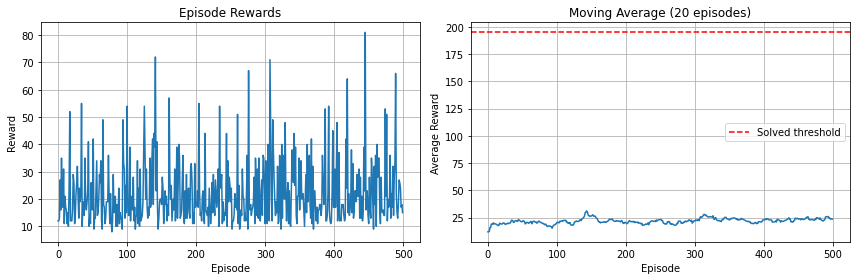


Training completed!
Final average reward (last 100 episodes): 23.28


In [7]:

# Main execution
if __name__ == "__main__":
    # Train the agent
    rewards = train_ppo()
    
    # Plot results
    plot_results(rewards)
    
    print("\nTraining completed!")
    print(f"Final average reward (last 100 episodes): {np.mean(rewards[-100:]):.2f}")